
🎯 주요 내용:
- 토큰화, 벡터화, 임베딩의 차이점
- TF-IDF와 코사인 유사도 설명
- OpenAI Embedding API 실습
- 3D 임베딩 시각화 및 유사도 분석
- 벡터 DB 저장 및 활용 예시

* 주요 링크 :
    * https://platform.openai.com/tokenizer
    * https://projector.tensorflow.org/
    * https://huggingface.co/models?sort=trending&search=embedding
    * https://damien0x0023.github.io/rnnExplainer/

In [1]:
!pip install -Uq openai
!pip install -Uq koreanize-matplotlib
import koreanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 964.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.2 MB/s eta 0:00:00


In [2]:
import openai
import csv
import time
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata

openai.api_key = userdata.get('OPENAI_API_KEY')

In [3]:
texts = ['혼자 공부하는 머신러닝+딥러닝',
 '밑바닥부터 시작하는 딥러닝 1',
 '혼자 공부하는 컴퓨터 구조+운영체제',
 '챗GPT 일타강사의 직장인 업무 만렙 공략집',
 '혼자 공부하는 네트워크',
 '모두를 위한 양자 컴퓨터',
 '핸즈온 머신러닝',
 '이것이 취업을 위한 컴퓨터 과학이다 with CS 기술 면접',
 '혼자 공부하는 자바',
 '개발자를 위한 필수 수학',
 '이것이 취업을 위한 코딩 테스트다 with 파이썬',
 '밑바닥부터 시작하는 딥러닝 2',
 '이것이 C#이다',
 '이것이 자료구조+알고리즘이다 with C 언어',
 'NLP와 LLM 실전 가이드',
 '소프트웨어 엔지니어 가이드북',
 '밑바닥부터 시작하는 딥러닝 5',
 '개발자 기술 면접 노트',
 '그림으로 배우는 도커',
 '혼자 공부하는 SQL',
 '개발자를 위한 실전 선형대수학',
 '밑바닥부터 시작하는 딥러닝 4',
 '한 권으로 배우는 도커 & 쿠버네티스',
 '실무로 통하는 인과추론 with 파이썬',
 '처음 배우는 애저',
 'AGI의 시대',
 '밑바닥부터 시작하는 딥러닝 3',
 '헤드 퍼스트 디자인 패턴',
 '플랫폼 엔지니어링',
 '사토시의 서',
 '한 권으로 배우는 게임 프로그래밍',
 '리팩터링 2판',
 '팀 개발을 위한 Git, GitHub 시작하기',
 '도메인 주도 개발 시작하기',
 '견고한 데이터 엔지니어링',
 '몽고DB 완벽 가이드',
 '파이썬 라이브러리를 활용한 데이터 분석',
 '전문가를 위한 파이썬',
 '제대로 시작하는 챗GPT와 AI 활용 with 파이썬',
 '이것이 MySQL이다',
 '혼자 공부하는 첫 프로그래밍 with 파이썬',
 'AI를 위한 필수 수학',
 'GPT API를 활용한 인공지능 앱 개발',
 '고작 다섯 명이 한 말을 어떻게 믿어요?',
 '월 20달러로 비즈니스 글쓰기 with 챗GPT',
 '프로덕트 매니지먼트',
 '일잘러의 비밀, 엑셀 대신 파이썬으로 업무 자동화하기',
 'AI 시대의 프로그래머',
 'SQL 첫걸음',
 '이지 러스트']
len(texts)

50

In [4]:
# prompt: texts 내용 tf-idf로 토큰화

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

# TF-IDF 행렬 출력
print(tfidf_matrix.toarray())

# TF-IDF 어휘 목록 출력
print(tfidf_vectorizer.get_feature_names_out())

[[0.         0.         0.         ... 0.46383605 0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.36661165 0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
['20달러로' '2판' 'agi의' 'ai' 'ai를' 'api를' 'cs' 'git' 'github' 'gpt' 'llm'
 'mysql이다' 'nlp와' 'sql' 'with' '가이드' '가이드북' '개발' '개발을' '개발자' '개발자를' '게임'
 '견고한' '고작' '공략집' '공부하는' '과학이다' '구조' '권으로' '그림으로' '글쓰기' '기술' '네트워크' '노트'
 '다섯' '대신' '데이터' '도메인' '도커' '디자인' '딥러닝' '라이브러리를' '러스트' '리팩터링' '만렙' '말을'
 '매니지먼트' '머신러닝' '면접' '명이' '모두를' '몽고db' '믿어요' '밑바닥부터' '배우는' '분석' '비밀'
 '비즈니스' '사토시의' '선형대수학' '소프트웨어' '수학' '시대' '시대의' '시작하기' '시작하는' '실무로' '실전'
 '알고리즘이다' '애저' '양자' '어떻게' '언어' '업무' '엑셀' '엔지니어' '엔지니어링' '완벽' '운영체제' '위한'
 '이것이' '이다' '이지' '인공지능' '인과추론' '일잘러의' '일타강사의' '자동화하기'

In [5]:
import pandas as pd
df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
df.style.background_gradient(cmap='Blues')

In [6]:
# ✅ 임베딩 생성 함수 (지연 포함)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding

# ✅ 결과 저장할 리스트
embeddings = []
metadata = []

# ✅ 임베딩 생성 루프
for idx, text in enumerate(texts):
    print(f"Embedding {idx+1}/{len(texts)}: {text}")
    try:
        emb = get_embedding(text)
        embeddings.append(emb)
        metadata.append(text)
        time.sleep(0.1)  # API rate limit 회피용
    except Exception as e:
        print(f"Error embedding '{text}':", e)
        embeddings.append([0.0]*1536)  # fallback
        metadata.append(text)

# ✅ embeddings.tsv 저장
with open("embeddings.tsv", "w", newline="") as f:
    writer = csv.writer(f, delimiter="\t")
    for emb in embeddings:
        writer.writerow(emb)

# ✅ metadata.tsv 저장
with open("metadata.tsv", "w", newline="") as f:
    for text in metadata:
        f.write(text + "\n")

print("✅ TSV 파일 저장 완료: embeddings.tsv, metadata.tsv")


Embedding 1/50: 혼자 공부하는 머신러닝+딥러닝
Embedding 2/50: 밑바닥부터 시작하는 딥러닝 1
Embedding 3/50: 혼자 공부하는 컴퓨터 구조+운영체제
Embedding 4/50: 챗GPT 일타강사의 직장인 업무 만렙 공략집
Embedding 5/50: 혼자 공부하는 네트워크
Embedding 6/50: 모두를 위한 양자 컴퓨터
Embedding 7/50: 핸즈온 머신러닝
Embedding 8/50: 이것이 취업을 위한 컴퓨터 과학이다 with CS 기술 면접
Embedding 9/50: 혼자 공부하는 자바
Embedding 10/50: 개발자를 위한 필수 수학
Embedding 11/50: 이것이 취업을 위한 코딩 테스트다 with 파이썬
Embedding 12/50: 밑바닥부터 시작하는 딥러닝 2
Embedding 13/50: 이것이 C#이다
Embedding 14/50: 이것이 자료구조+알고리즘이다 with C 언어
Embedding 15/50: NLP와 LLM 실전 가이드
Embedding 16/50: 소프트웨어 엔지니어 가이드북
Embedding 17/50: 밑바닥부터 시작하는 딥러닝 5
Embedding 18/50: 개발자 기술 면접 노트
Embedding 19/50: 그림으로 배우는 도커
Embedding 20/50: 혼자 공부하는 SQL
Embedding 21/50: 개발자를 위한 실전 선형대수학
Embedding 22/50: 밑바닥부터 시작하는 딥러닝 4
Embedding 23/50: 한 권으로 배우는 도커 & 쿠버네티스
Embedding 24/50: 실무로 통하는 인과추론 with 파이썬
Embedding 25/50: 처음 배우는 애저
Embedding 26/50: AGI의 시대
Embedding 27/50: 밑바닥부터 시작하는 딥러닝 3
Embedding 28/50: 헤드 퍼스트 디자인 패턴
Embedding 29/50: 플랫폼 엔지니어링
Embedding 30/50: 사토시의 서
Embedding 31/50:

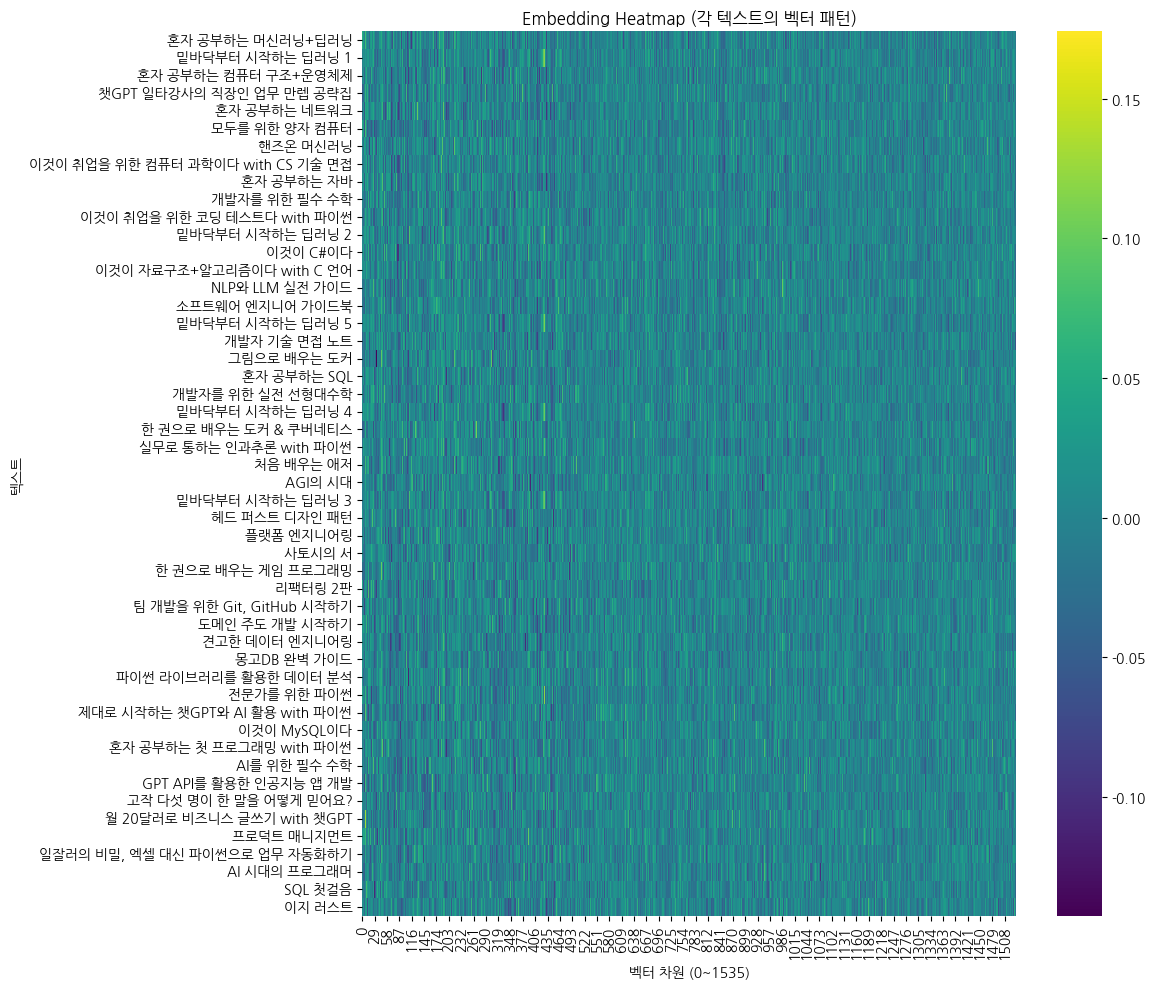

In [7]:
embedding_array = np.array(embeddings)

# 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(embedding_array, cmap='viridis', cbar=True)
plt.yticks(np.arange(len(texts)) + 0.5, texts, rotation=0)
plt.title("Embedding Heatmap (각 텍스트의 벡터 패턴)")
plt.xlabel("벡터 차원 (0~1535)")
plt.ylabel("텍스트")
plt.tight_layout()
plt.show()

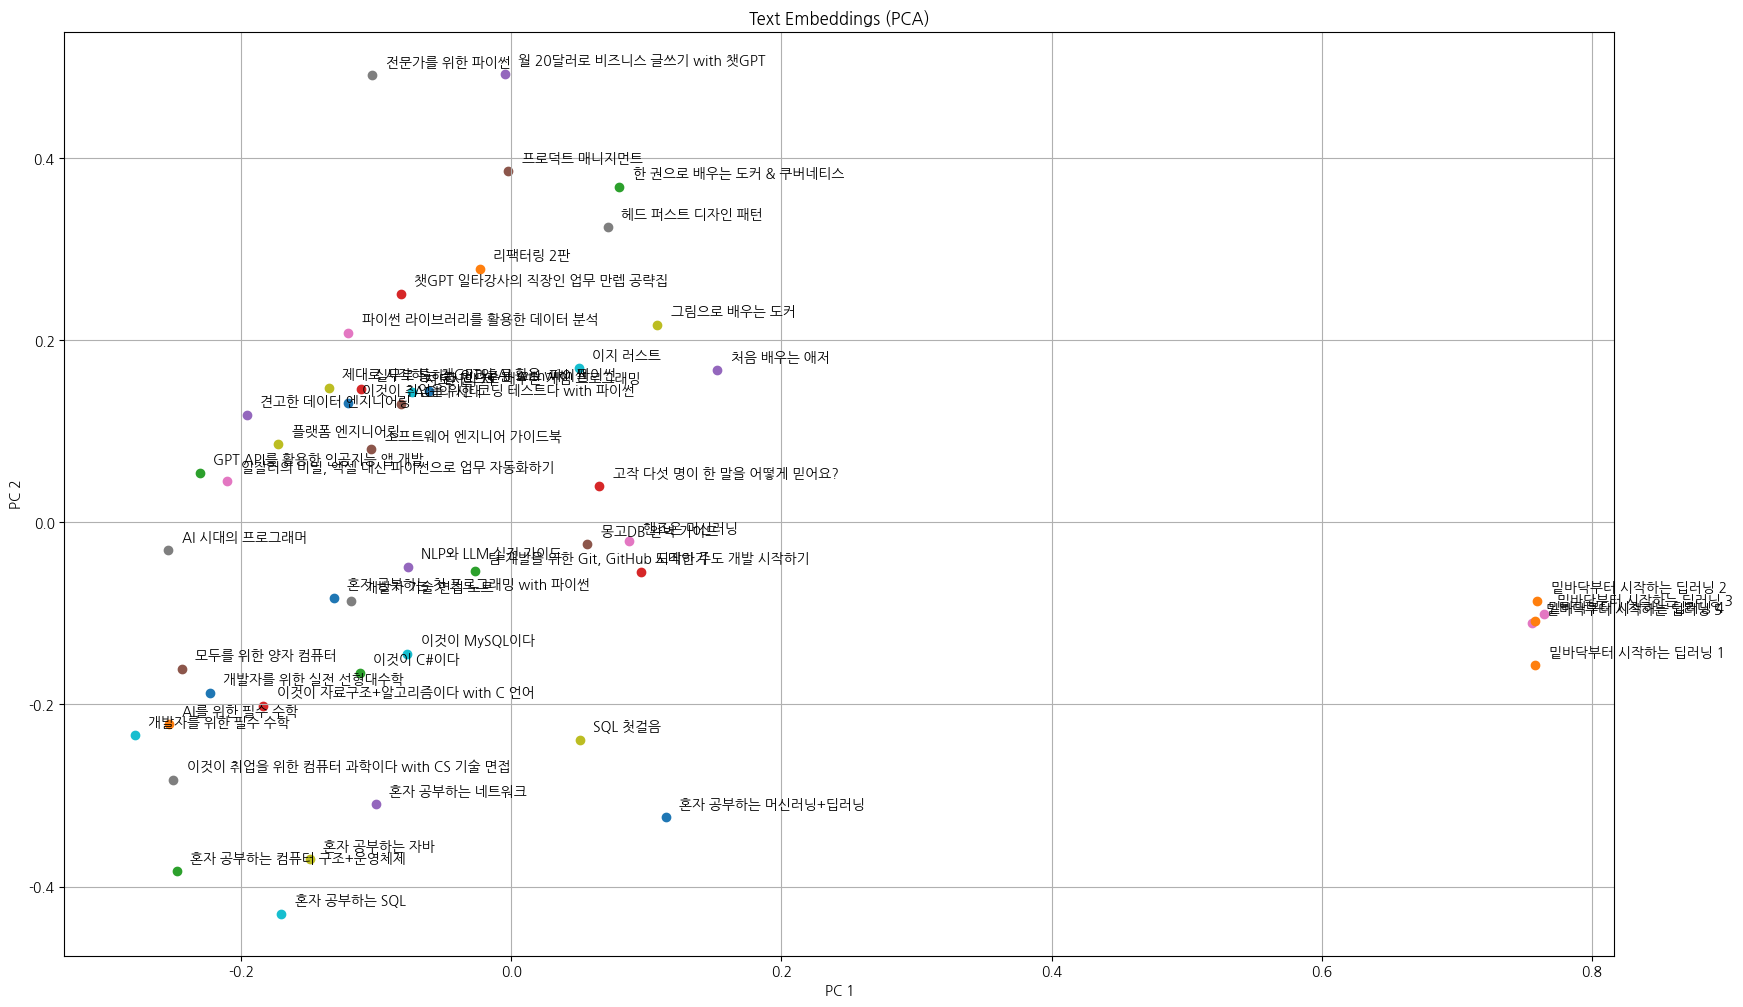

In [8]:
from sklearn.decomposition import PCA

# PCA로 2차원 축소
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# 시각화
plt.figure(figsize=(20, 12))
for i, label in enumerate(texts):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, label, fontsize=10)

plt.title("Text Embeddings (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.show()

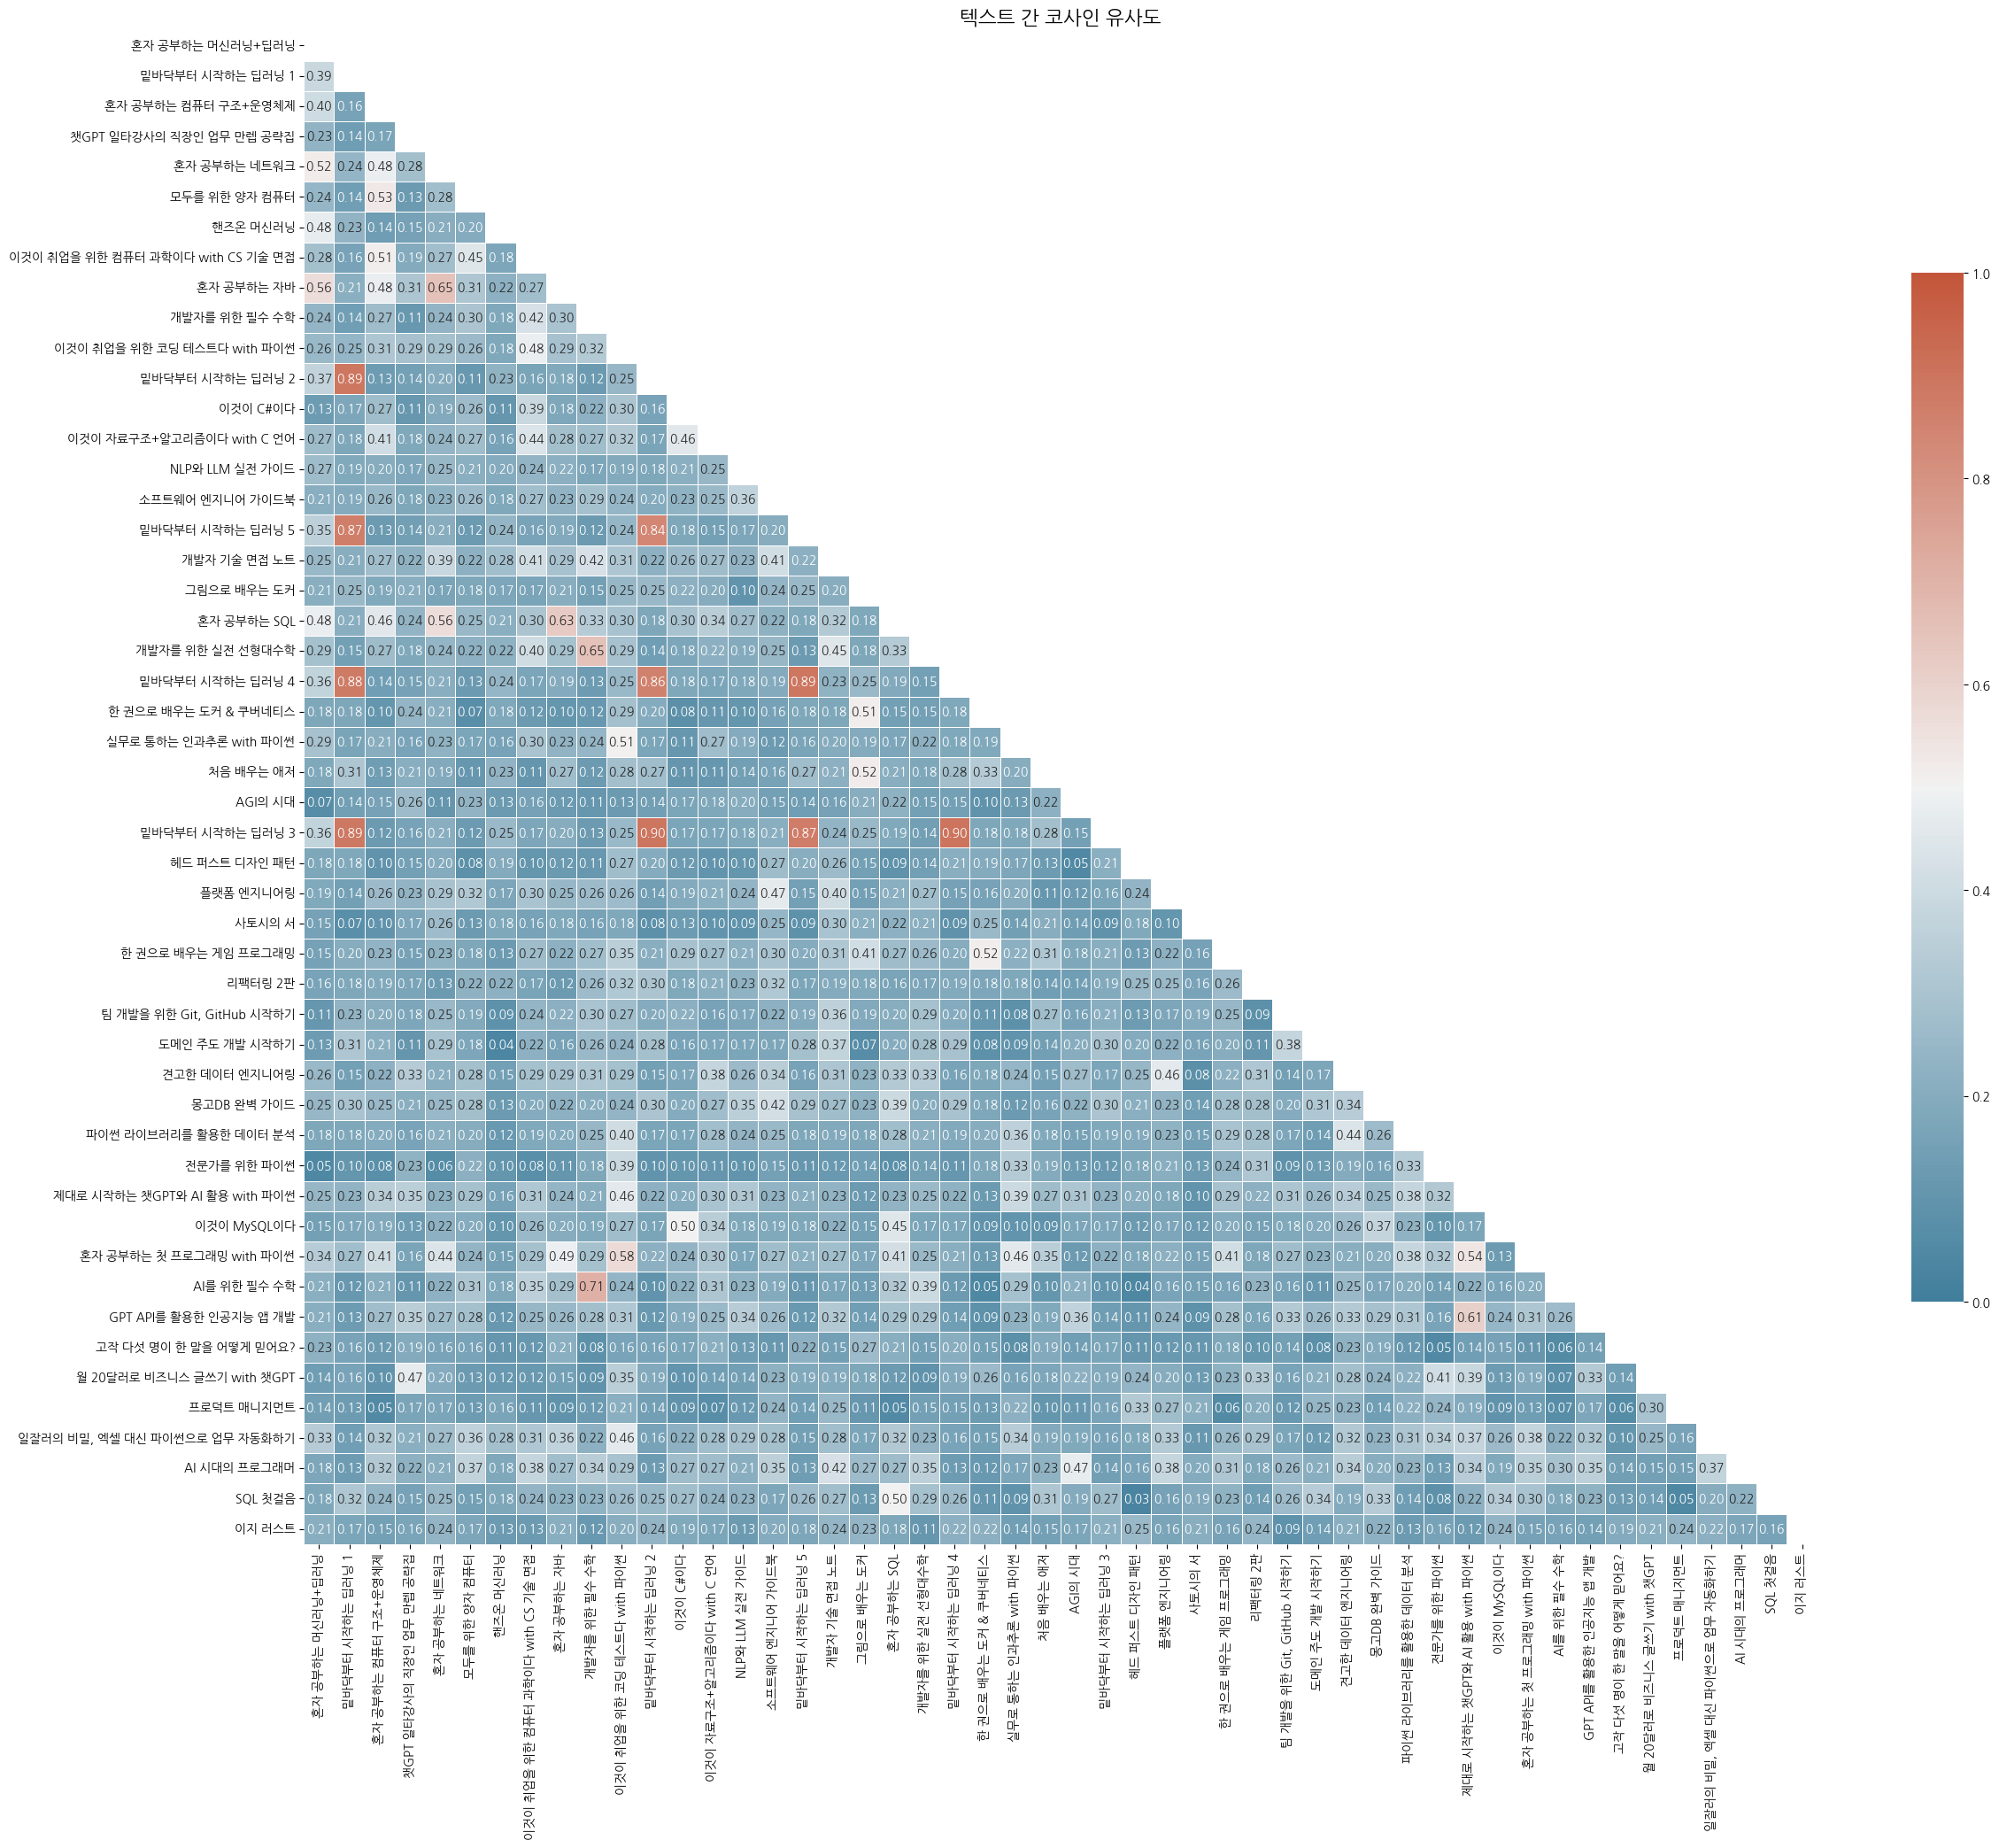

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# 코사인 유사도 계산
similarity_matrix = cosine_similarity(embedding_array)

# 유사도 히트맵 시각화
plt.figure(figsize=(25,25))
mask = np.triu(np.ones_like(similarity_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(similarity_matrix,
            mask=mask,
            cmap=cmap,
            vmax=1,
            vmin=0,
            center=0.5,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .5},
            annot=True,
            fmt=".2f")

plt.yticks(np.arange(len(metadata)) + 0.5, metadata, rotation=0)
plt.xticks(np.arange(len(metadata)) + 0.5, metadata, rotation=90)
plt.title("텍스트 간 코사인 유사도", fontsize=16)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=300)
plt.show()